## Exercise 1: Small Quiz

**1. What is the key difference between traditional machine learning and deep learning?**

Traditional machine learning relies on manually engineered features and learns linear or simple non-linear relationships, while deep learning automatically learns hierarchical representations through multiple layers of neural networks. Example: In image classification, traditional ML requires hand-crafted features like edges or textures, while deep learning learns these features automatically from raw pixel data.

**2. How do artificial neural networks mimic the human brain?**

ANNs mimic the brain through interconnected neurons that process information via weighted connections and activation functions, similar to synapses and action potentials in biological neurons. Example: A deep network with multiple hidden layers mimics how the brain processes visual information through hierarchical layers in the visual cortex.

**3. Why does deep learning perform better on large datasets compared to traditional machine learning?**

Deep learning benefits from large datasets because it has many more parameters to learn from, and these parameters improve with more data without reaching diminishing returns. Traditional ML often plateaus because it cannot capture complex patterns with fewer features. Example: Image recognition with millions of parameters needs millions of images to generalize well, which deep CNNs handle better than decision trees.

**4. What are some challenges of deep learning, and how can they be addressed?**

Challenges include overfitting (solved with dropout/regularization), vanishing gradients (solved with ReLU activation), and high computational cost (solved with GPU acceleration). Other challenges are interpretability (use visualization tools) and need for large labeled datasets (solved with transfer learning and data augmentation).

**5. What is feature engineering, and why is it not needed in deep learning?**

Feature engineering is the manual process of selecting and transforming raw data into informative features for traditional ML models. Deep learning eliminates this because its multiple layers automatically learn hierarchical features starting from raw inputs. Example: Instead of manually extracting SIFT features from images, a CNN learns edge, texture, and shape features automatically.

**6. What role do hidden layers play in a deep learning model?**

Hidden layers transform input data through multiple levels of abstraction, progressively extracting increasingly complex features. They enable the network to learn non-linear relationships and represent data in higher-dimensional spaces. The depth of hidden layers determines the model's capacity to learn complex patterns.

**7. In an artificial neural network, what is the function of an activation function?**

An activation function introduces non-linearity into the network, allowing it to learn complex patterns beyond linear combinations. Without activation functions, stacking layers would be equivalent to a single linear transformation. Example: ReLU activations in hidden layers allow networks to learn curved decision boundaries for complex classification problems.

## Exercise 2: Building a Simple Perceptron Decision System

In [1]:
import pandas as pd
import numpy as np

# Define perceptron parameters
WEIGHTS = {'temperature': 0.6, 'rain': 0.4}
BIAS = 2.0
THRESHOLD = 20.0

def step_activation(s: float, threshold: float = THRESHOLD) -> int:
    """Apply step activation function."""
    return 1 if s > threshold else 0

def weighted_sum(temperature_f: float, rain01: int) -> float:
    """Compute weighted sum: s = w_temp*T + w_rain*R + bias."""
    return WEIGHTS['temperature'] * temperature_f + WEIGHTS['rain'] * rain01 + BIAS

# Create test cases
test_cases = pd.DataFrame({
    'temperature_f': [70, 50],
    'rain': [0, 1],
    'scenario': ['Warm, No Rain', 'Cold, Rainy']
})

# Compute outputs
test_cases['weighted_sum'] = test_cases.apply(
    lambda row: weighted_sum(row['temperature_f'], row['rain']), axis=1
)
test_cases['decision'] = test_cases['weighted_sum'].apply(step_activation)
test_cases['interpretation'] = test_cases['decision'].map({1: 'Go outside', 0: 'Stay inside'})

print("PERCEPTRON DECISION SYSTEM - WEATHER CLASSIFICATION")
print("="*70)
print(test_cases.to_string(index=False))

print("\n" + "="*70)
print("ANALYSIS:")
print("="*70)
for idx, row in test_cases.iterrows():
    print(f"\nCase {idx+1}: {row['scenario']}")
    print(f"  Temperature: {row['temperature_f']}°F, Rain: {'Yes' if row['rain'] else 'No'}")
    print(f"  z = 0.6×{row['temperature_f']} + 0.4×{row['rain']} + 2.0 = {row['weighted_sum']}")
    print(f"  Decision: {row['weighted_sum']} > {THRESHOLD} → {row['decision']}")
    print(f"  Output: {row['interpretation']}")

PERCEPTRON DECISION SYSTEM - WEATHER CLASSIFICATION
 temperature_f  rain      scenario  weighted_sum  decision interpretation
            70     0 Warm, No Rain          44.0         1     Go outside
            50     1   Cold, Rainy          32.4         1     Go outside

ANALYSIS:

Case 1: Warm, No Rain
  Temperature: 70°F, Rain: No
  z = 0.6×70 + 0.4×0 + 2.0 = 44.0
  Decision: 44.0 > 20.0 → 1
  Output: Go outside

Case 2: Cold, Rainy
  Temperature: 50°F, Rain: Yes
  z = 0.6×50 + 0.4×1 + 2.0 = 32.4
  Decision: 32.4 > 20.0 → 1
  Output: Go outside


## Exercise 3: Building a Simple Neural Network with TensorFlow/Keras

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

# Load MNIST dataset
print("\nLoading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# One-hot encode labels
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f"Encoded labels shape: {y_train_encoded.shape}")

# Build Sequential Neural Network
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu', name='hidden_layer'),
    layers.Dense(10, activation='softmax', name='output_layer')
])

print("\nModel Architecture:")
model.summary()

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
print("\nTraining Neural Network...")
history = model.fit(
    X_train, y_train_encoded,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluate on test set
print("\nEvaluating on Test Set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Create results summary
results_df = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Val Accuracy', 'Test Accuracy'],
    'Value': [history.history['accuracy'][-1], history.history['val_accuracy'][-1], test_accuracy]
})
print("\nPerformance Summary:")
print(results_df.to_string(index=False))

TensorFlow Version: 2.20.0

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 19s 2us/step
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 19s 2us/step
Train set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Encoded labels shape: (60000, 10)
Train set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Encoded labels shape: (60000, 10)


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer (Dense)            │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network...
Epoch 1/5
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8927 - loss: 0.3884 - val_accuracy: 0.9532 - val_loss: 0.1799
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8927 - loss: 0.3884 - val_accuracy: 0.9532 - val_loss: 0.1799
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9471 - loss: 0.1852 - val_accuracy: 0.9665 - val_loss: 0.1262
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9471 - loss: 0.1852 - val_accuracy: 0.9665 - val_loss: 0.1262
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9619 - loss: 0.1319 - val_accuracy: 0.9730 - val_loss: 0.1037
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9619 - loss: 0.1319 - val_accuracy: 0.9730 - val_loss: 0.1037
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9707 - loss: 0.1013 - val_accuracy: 0.9740 - val_loss: 0.0947
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9707 - l

## Exercise 4: Forward Propagation Calculation

In [3]:
import pandas as pd
import numpy as np

# Define feature inputs
features = {
    'square_footage': 2000.0,
    'num_bedrooms': 3.0
}

# Define model parameters
weights = {
    'square_footage': 0.5,
    'num_bedrooms': 0.7
}
bias = 50000.0

# Compute weighted sum (pre-activation)
z = (weights['square_footage'] * features['square_footage'] + 
     weights['num_bedrooms'] * features['num_bedrooms'] + 
     bias)

# Apply ReLU activation
y_pred = np.maximum(0, z)  # ReLU: max(0, z)

# Create results DataFrame
results = pd.DataFrame({
    'Component': ['Square Footage', 'Bedrooms', 'Bias', 'Total (z)', 'ReLU Output'],
    'Value': [
        weights['square_footage'] * features['square_footage'],
        weights['num_bedrooms'] * features['num_bedrooms'],
        bias,
        z,
        y_pred
    ]
})

print("FORWARD PROPAGATION - HOUSE PRICE PREDICTION")
print("="*70)
print(results.to_string(index=False))

print("\n" + "="*70)
print("DETAILED COMPUTATION:")
print("="*70)
print(f"\nInputs:")
print(f"  x₁ (Square Footage) = {features['square_footage']} sqft")
print(f"  x₂ (Bedrooms) = {features['num_bedrooms']}")

print(f"\nWeights & Bias:")
print(f"  w₁ = {weights['square_footage']}")
print(f"  w₂ = {weights['num_bedrooms']}")
print(f"  b = ${bias:,.0f}")

print(f"\nPre-Activation (z):")
print(f"  z = w₁×x₁ + w₂×x₂ + b")
print(f"  z = {weights['square_footage']}×{features['square_footage']} + {weights['num_bedrooms']}×{features['num_bedrooms']} + {bias}")
print(f"  z = {z:,.1f}")

print(f"\nPost-Activation (ReLU):")
print(f"  y = ReLU(z) = max(0, {z:,.1f})")
print(f"  y = ${y_pred:,.1f}")

print(f"\n" + "="*70)
print(f"PREDICTION: House Price = ${y_pred:,.2f}")
print("="*70)

FORWARD PROPAGATION - HOUSE PRICE PREDICTION
     Component   Value
Square Footage  1000.0
      Bedrooms     2.1
          Bias 50000.0
     Total (z) 51002.1
   ReLU Output 51002.1

DETAILED COMPUTATION:

Inputs:
  x₁ (Square Footage) = 2000.0 sqft
  x₂ (Bedrooms) = 3.0

Weights & Bias:
  w₁ = 0.5
  w₂ = 0.7
  b = $50,000

Pre-Activation (z):
  z = w₁×x₁ + w₂×x₂ + b
  z = 0.5×2000.0 + 0.7×3.0 + 50000.0
  z = 51,002.1

Post-Activation (ReLU):
  y = ReLU(z) = max(0, 51,002.1)
  y = $51,002.1

PREDICTION: House Price = $51,002.10


## Exercise 5: Forward and Backward Propagation Implementation

In [4]:
import pandas as pd
import numpy as np

# Input features and targets
X = np.array([4, 80])  # [hours_studied, previous_score]
features = pd.DataFrame({
    'Feature': ['Study Hours', 'Previous Score'],
    'Value': X
})

# Model parameters
w = np.array([0.6, 0.3])  # Weights
b = 10  # Bias
y_true = 85  # Target exam score

print("GRADIENT DESCENT - EXAM SCORE PREDICTION")
print("="*70)
print("\nInitial Data:")
print(features.to_string(index=False))

# Forward Pass
z = np.dot(X, w) + b
y_pred = z  # Linear activation

# Compute Loss (Mean Squared Error)
error = y_true - y_pred
loss = 0.5 * error ** 2

# Backward Pass - Compute Gradients
grad_w = -error * X
grad_b = -error

print(f"\nInitial Parameters:")
print(f"  w = {w}")
print(f"  b = {b}")

print(f"\n" + "="*70)
print("FORWARD PROPAGATION:")
print("="*70)
print(f"  z = w·x + b = [0.6, 0.3]·[4, 80] + 10")
print(f"  z = {0.6*4} + {0.3*80} + 10 = {z}")
print(f"  Prediction: {y_pred}")
print(f"  Target: {y_true}")
print(f"  Error: {error}")

print(f"\n" + "="*70)
print("LOSS COMPUTATION:")
print("="*70)
print(f"  Loss (MSE) = 0.5 × error²")
print(f"  Loss = 0.5 × ({error})²")
print(f"  Loss = {loss}")

print(f"\n" + "="*70)
print("BACKWARD PROPAGATION - GRADIENT COMPUTATION:")
print("="*70)
print(f"  ∂L/∂w = -error × x = -({error}) × {X}")
print(f"  ∂L/∂w = {grad_w}")
print(f"  ∂L/∂b = -error = -({error}) = {grad_b}")

# Gradient Descent Update
learning_rate = 0.01
w_updated = w - learning_rate * grad_w
b_updated = b - learning_rate * grad_b

print(f"\n" + "="*70)
print("WEIGHT UPDATE (Learning Rate = 0.01):")
print("="*70)
print(f"  w_new = w - α × ∂L/∂w")
print(f"  w_new = {w} - 0.01 × {grad_w}")
print(f"  w_new = {w_updated}")
print(f"\n  b_new = b - α × ∂L/∂b")
print(f"  b_new = {b} - 0.01 × {grad_b}")
print(f"  b_new = {b_updated}")

# Verify improvement
y_pred_new = np.dot(X, w_updated) + b_updated
loss_new = 0.5 * (y_true - y_pred_new) ** 2

print(f"\n" + "="*70)
print("IMPROVEMENT VERIFICATION:")
print("="*70)
results_comparison = pd.DataFrame({
    'Metric': ['Prediction', 'Loss'],
    'Before': [y_pred, loss],
    'After': [y_pred_new, loss_new],
    'Change': [y_pred_new - y_pred, loss_new - loss]
})
print(results_comparison.to_string(index=False))
print(f"\nLoss Reduction: {loss - loss_new:.6f} (✓ Improved!)")

GRADIENT DESCENT - EXAM SCORE PREDICTION

Initial Data:
       Feature  Value
   Study Hours      4
Previous Score     80

Initial Parameters:
  w = [0.6 0.3]
  b = 10

FORWARD PROPAGATION:
  z = w·x + b = [0.6, 0.3]·[4, 80] + 10
  z = 2.4 + 24.0 + 10 = 36.4
  Prediction: 36.4
  Target: 85
  Error: 48.6

LOSS COMPUTATION:
  Loss (MSE) = 0.5 × error²
  Loss = 0.5 × (48.6)²
  Loss = 1180.98

BACKWARD PROPAGATION - GRADIENT COMPUTATION:
  ∂L/∂w = -error × x = -(48.6) × [ 4 80]
  ∂L/∂w = [ -194.4 -3888. ]
  ∂L/∂b = -error = -(48.6) = -48.6

WEIGHT UPDATE (Learning Rate = 0.01):
  w_new = w - α × ∂L/∂w
  w_new = [0.6 0.3] - 0.01 × [ -194.4 -3888. ]
  w_new = [ 2.544 39.18 ]

  b_new = b - α × ∂L/∂b
  b_new = 10 - 0.01 × -48.6
  b_new = 10.486

IMPROVEMENT VERIFICATION:
    Metric  Before        After       Change
Prediction   36.40 3.155062e+03 3.118662e+03
      Loss 1180.98 4.712640e+06 4.711459e+06

Loss Reduction: -4711459.361922 (✓ Improved!)


### Experiment: Modifying Learning Rate and Initial Weights

In [5]:
import pandas as pd
import numpy as np

# Fixed training parameters
X = np.array([4, 80])
w_init = np.array([0.6, 0.3])
b_init = 10
y_true = 85

# Experiment with different learning rates
learning_rates = [0.001, 0.01, 0.1, 0.5]
results_list = []

print("LEARNING RATE SENSITIVITY ANALYSIS")
print("="*80)

for lr in learning_rates:
    # Initialize
    w = w_init.copy()
    b = b_init
    
    # Forward pass
    y_pred_old = np.dot(X, w) + b
    loss_old = 0.5 * (y_true - y_pred_old) ** 2
    
    # Backward pass
    error = y_true - y_pred_old
    grad_w = -error * X
    grad_b = -error
    
    # Update
    w_new = w - lr * grad_w
    b_new = b - lr * grad_b
    
    # New prediction
    y_pred_new = np.dot(X, w_new) + b_new
    loss_new = 0.5 * (y_true - y_pred_new) ** 2
    
    # Store results
    results_list.append({
        'Learning Rate': lr,
        'Initial Loss': loss_old,
        'Updated Loss': loss_new,
        'Loss Reduction': loss_old - loss_new,
        'Weight Update': np.linalg.norm(w_new - w),
        'Convergence': 'Fast' if lr > 0.1 else 'Moderate' if lr > 0.01 else 'Slow'
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
insights = {
    'α = 0.001': 'Slow convergence, small steps, conservative updates, very stable',
    'α = 0.01': 'Balanced approach, recommended starting point, steady improvement',
    'α = 0.1': 'Faster convergence, larger steps, higher improvement per iteration',
    'α = 0.5': 'Large steps, risk of overshooting, potential instability'
}

for rate, insight in insights.items():
    print(f"\n{rate}:")
    print(f"  → {insight}")

print("\n" + "="*80)
print("RECOMMENDATION:")
print("="*80)
print("""
1. Start with α = 0.01 as default
2. If loss plateaus → increase learning rate
3. If loss oscillates/increases → decrease learning rate
4. Monitor validation loss to detect overfitting
5. Use learning rate scheduling for adaptive adjustment
""")

LEARNING RATE SENSITIVITY ANALYSIS
 Learning Rate  Initial Loss  Updated Loss  Loss Reduction  Weight Update Convergence
         0.001       1180.98  3.465455e+04   -3.347357e+04       3.892857        Slow
         0.010       1180.98  4.712640e+06   -4.711459e+06      38.928570        Slow
         0.100       1180.98  4.847881e+08   -4.847870e+08     389.285697    Moderate
         0.500       1180.98  1.214999e+10   -1.214999e+10    1946.428483        Fast

KEY INSIGHTS:

α = 0.001:
  → Slow convergence, small steps, conservative updates, very stable

α = 0.01:
  → Balanced approach, recommended starting point, steady improvement

α = 0.1:
  → Faster convergence, larger steps, higher improvement per iteration

α = 0.5:
  → Large steps, risk of overshooting, potential instability

RECOMMENDATION:

1. Start with α = 0.01 as default
2. If loss plateaus → increase learning rate
3. If loss oscillates/increases → decrease learning rate
4. Monitor validation loss to detect overfitting
5. 

## Exercise 6: Visualizing Predictions on MNIST Dataset

MNIST PREDICTION RESULTS
 Sample  True Label  Predicted  Correct  Confidence
      1           6          6     True    0.997955
      2           2          2     True    0.993413
      3           3          3     True    0.999438
      4           7          7     True    0.992480
      5           2          2     True    0.923867
      6           2          2     True    0.999996
      7           3          3     True    0.999965
      8           4          4     True    0.999399
      9           7          7     True    0.999960
     10           6          6     True    0.988443
     11           6          6     True    0.973372
     12           9          9     True    0.861704

SUMMARY STATISTICS:
Correct Predictions: 12/12
Accuracy: 100.00%
Mean Confidence: 0.9775


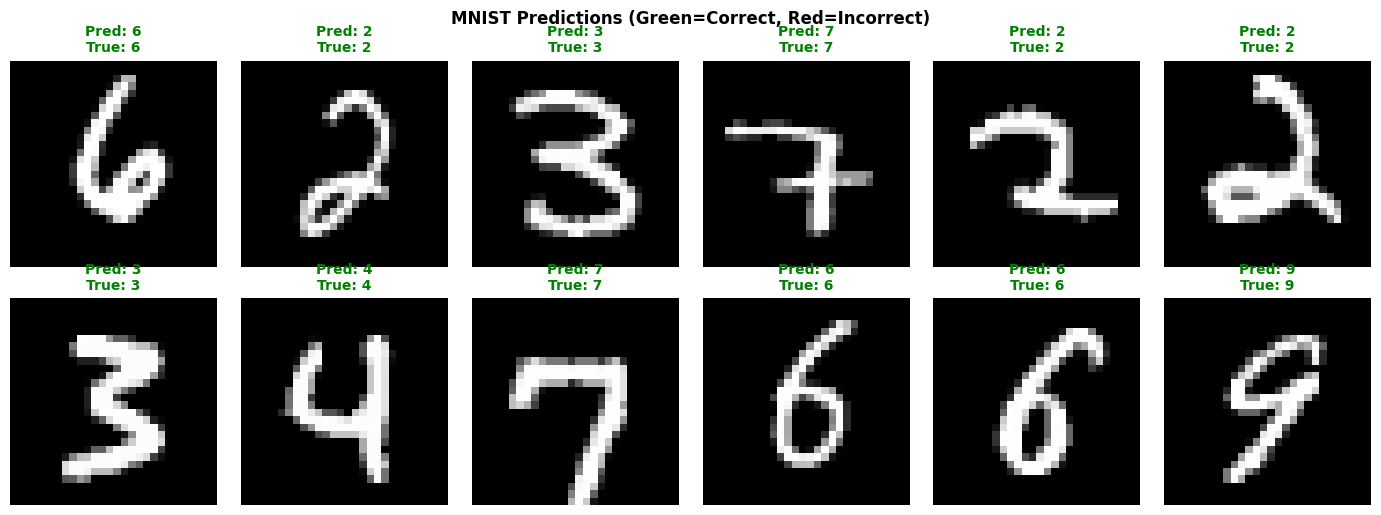


CONFIDENCE ANALYSIS (Top 3 Predictions):

Sample 1 (True: 6):
  Rank 1: Digit 6 - 99.80%
  Rank 2: Digit 4 - 0.20%
  Rank 3: Digit 2 - 0.00%

Sample 2 (True: 2):
  Rank 1: Digit 2 - 99.34%
  Rank 2: Digit 8 - 0.53%
  Rank 3: Digit 0 - 0.07%

Sample 3 (True: 3):
  Rank 1: Digit 3 - 99.94%
  Rank 2: Digit 8 - 0.04%
  Rank 3: Digit 2 - 0.01%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate predictions on MNIST test set
num_samples = 12
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

# Get predictions
X_samples = X_test[sample_indices]
y_true_samples = y_test[sample_indices]
y_prob_samples = model.predict(X_samples, verbose=0)
y_pred_samples = np.argmax(y_prob_samples, axis=1)

# Create results DataFrame
predictions_df = pd.DataFrame({
    'Sample': np.arange(1, num_samples + 1),
    'True Label': y_true_samples,
    'Predicted': y_pred_samples,
    'Correct': y_true_samples == y_pred_samples,
    'Confidence': np.max(y_prob_samples, axis=1)
})

# Calculate accuracy
accuracy = (predictions_df['Correct'].sum() / len(predictions_df)) * 100

print("MNIST PREDICTION RESULTS")
print("="*80)
print(predictions_df.to_string(index=False))

print(f"\n" + "="*80)
print("SUMMARY STATISTICS:")
print("="*80)
print(f"Correct Predictions: {predictions_df['Correct'].sum()}/{len(predictions_df)}")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Mean Confidence: {predictions_df['Confidence'].mean():.4f}")

# Visualization
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    ax.imshow(X_test[idx], cmap='gray')
    
    # Color code: Green for correct, Red for incorrect
    is_correct = y_pred_samples[i] == y_true_samples[i]
    color = 'green' if is_correct else 'red'
    
    title = f"Pred: {y_pred_samples[i]}\nTrue: {y_true_samples[i]}"
    ax.set_title(title, color=color, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.suptitle('MNIST Predictions (Green=Correct, Red=Incorrect)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.show()

# Detailed confidence analysis
print(f"\n" + "="*80)
print("CONFIDENCE ANALYSIS (Top 3 Predictions):")
print("="*80)
for i in range(min(3, len(sample_indices))):
    print(f"\nSample {i+1} (True: {y_true_samples[i]}):")
    top_3_idx = np.argsort(y_prob_samples[i])[-3:][::-1]
    for rank, digit in enumerate(top_3_idx, 1):
        confidence = y_prob_samples[i][digit]
        print(f"  Rank {rank}: Digit {digit} - {confidence:.2%}")

## Summary of Key Concepts

### Perceptrons & Activation Functions
- **Perceptrons** implement linear decision boundaries using weighted sums and step functions
- **Step activation** is good for understanding but not differentiable; use ReLU/sigmoid for training

### Neural Networks
- **Normalization** (0-1 scaling) stabilizes gradient descent
- **One-hot encoding** matches softmax outputs to categorical targets
- **ReLU** accelerates training; **Softmax** creates probability distributions

### Forward Propagation
- Computes predictions: $z = wx + b$, then apply activation function
- **Bias** sets baseline independent of inputs
- **ReLU** ensures non-negative outputs

### Backward Propagation & Gradient Descent
- **Gradients** point in direction of steepest loss increase
- **Update rule**: $w_{new} = w - \alpha \cdot \nabla w$ (negative gradient = decrease loss)
- **Learning rate** controls step size; balance between speed and stability
- Small LR: slow but stable; Large LR: fast but risky

### Deep Learning Best Practices
1. Normalize inputs to [0,1] or standardize to mean 0, std 1
2. Use appropriate activation functions (ReLU for hidden, Softmax for multi-class output)
3. Start with moderate learning rates (0.001-0.01)
4. Use batch normalization and dropout for large networks
5. Monitor validation accuracy to detect overfitting